
# Computational Physics: Root Finding (1D)

**Primary Goal**
- Implement and compare **Bisection**, **Newton-Raphson**, and **Secant** methods.
  



## 0. Background: What is root finding?
Given a function $f:\mathbb{R}\to\mathbb{R}$, find $x^*$ such that $f(x^*)=0$.

- **Bracketing methods** (e.g., **Bisection**) require an initial interval $[a,b]$ with a **sign change**: $f(a)f(b)<0$. They are **guaranteed** to converge (for continuous $f$), but can be slower.
- **Open methods** (e.g., **Newton-Raphson**, **Secant**) usually converge faster but need **good initial guesses** and may fail if conditions are poor (flat derivative, bad guess, etc.).


## 1. Imports (Begin with the beginning...)

In [2]:

import math
import numpy as np
import matplotlib.pyplot as plt

# For reproducibility in any random demos (not strictly needed here)
rng = np.random.default_rng(0)


## 2. Implementations: Bisection, Newton, Secant, & Brent

![You are missing root_find_fig.png](root_find_fig.png)

![Bisection slide](bisection_fig.png)

In [3]:

def bisection(f, a, b, tol=1e-10, max_iter=100):
    """Find a root in [a,b] assuming f is continuous and f(a)*f(b) < 0.
    
    Returns (x, history) where history is a list of |f| or interval widths.
    """
    fa, fb = f(a), f(b)
    if np.isnan(fa) or np.isnan(fb):
        raise ValueError("f(a) or f(b) is NaN; check your function/domain.")
    if fa * fb > 0:
        raise ValueError("Bisection requires a sign change: f(a)*f(b) < 0.")
    hist = []
    left, right = a, b
    for k in range(1, max_iter+1):
        mid = 0.5*(left + right)
        fm = f(mid)
        hist.append(abs(right - left))
        if fm == 0 or 0.5*(right - left) < tol:
            return mid, hist
        # Choose subinterval with sign change
        if fa * fm < 0:
            right = mid
            fb = fm
        else:
            left = mid
            fa = fm
    return mid, hist  # best effort


![You are missing newton_raphson_fig.png](newton_raphson_fig.png)

In [4]:

def newton(f, df, x0, tol=1e-12, max_iter=50):
    """Newton-Raphson method.
    
    Returns (x, history) where history contains |f(x_k)| values.
    """
    x = float(x0)
    hist = []
    for k in range(1, max_iter+1):
        fx = f(x)
        hist.append(abs(fx))
        dfx = df(x)
        if dfx == 0 or np.isnan(dfx):
            raise ZeroDivisionError("Derivative is zero/NaN; Newton step fails.")
        x_new = x - fx/dfx
        if abs(x_new - x) < tol:
            return x_new, hist
        x = x_new
    return x, hist


![Missing secant_method_fig_simple.png](secant_method_fig_simple.png)

![Missing secant_method_fig_cobweb.png](secant_method_fig_cobweb.png)

In [5]:

def secant(f, x0, x1, tol=1e-12, max_iter=80):
    """Secant method (derivative-free). Provide two starting guesses x0, x1.
    
    Returns (x, history) where history contains |f(x_k)| values.
    """
    x_prev = float(x0)
    x = float(x1)
    f_prev = f(x_prev)
    fx = f(x)
    hist = [abs(f_prev), abs(fx)]
    for k in range(2, max_iter+1):
        denom = fx - f_prev
        if denom == 0:
            raise ZeroDivisionError("Secant denominator zero; guesses produced same f-values.")
        x_new = x - fx*(x - x_prev)/denom
        if abs(x_new - x) < tol:
            return x_new, hist
        x_prev, f_prev = x, fx
        x, fx = x_new, f(x_new)
        hist.append(abs(fx))
    return x, hist


#### Best choice to try first: Brent's method

![Missing brent.png](brent.png)

#### Calling Brent's method

In [ ]:
from scipy import optimize

f = lambda x: x**3 - x - 2
root = optimize.brentq(f, 1.0, 2.0, xtol=1e-12, rtol=1e-12, maxiter=100)
print(round(root,3))  

#### Bare bones calling:

In [ ]:
root = optimize.brentq(f, 1.0, 2.0)
print(root)

In [ ]:
help(optimize.brentq)

## 3. Demo on a test function


Start gently with a classic nonlinear function
$$
f(x) = x^3 - x - 2
$$
which has a real root near $x \approx 1.521$.


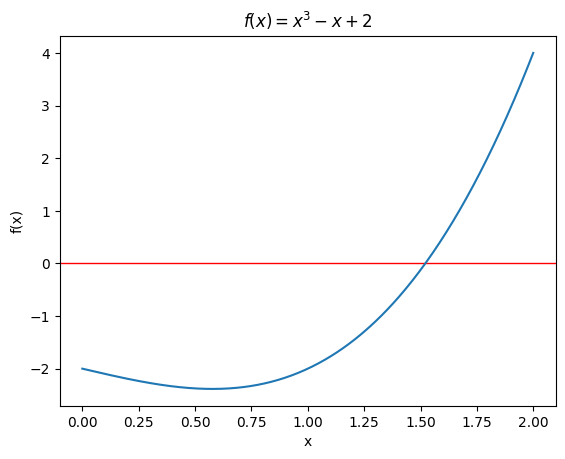

In [67]:

def f_test(x):
    return x**3 - x - 2.0

def df_test(x):
    return 3*x**2 - 1.0

# Visualize to choose brackets/guesses
xs = np.linspace(0, 2, 400)
ys = f_test(xs)

plt.figure()
plt.axhline(0, linewidth=1, c='red')
plt.plot(xs, ys)
# plt.title("f(x) = x^3 - x - 2")
plt.title("$f(x) = x^3 - x + 2$")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.show()


Bisection : 1.5213797068054191 f(root) = 5.061284724661164e-12
Newton    : 1.5213797068045676 f(root) = 0.0
Secant    : 1.5213797068045676 f(root) = 0.0


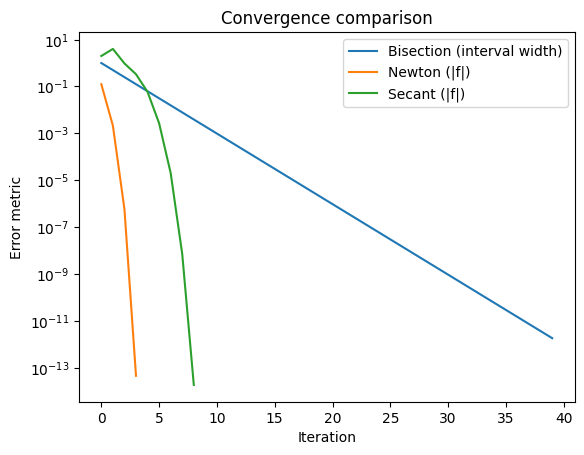

In [68]:

# Run methods
root_bis, hist_bis = bisection(f_test, a=1, b=2, tol=1e-12)
root_new, hist_new = newton(f_test, df_test, x0=1.5, tol=1e-12)
root_sec, hist_sec = secant(f_test, x0=1.0, x1=2.0, tol=1e-12)

print("Bisection :", root_bis, "f(root) =", f_test(root_bis))
print("Newton    :", root_new, "f(root) =", f_test(root_new))
print("Secant    :", root_sec, "f(root) =", f_test(root_sec))

# Convergence histories (semilogy of residuals or interval width)
plt.figure()
plt.semilogy(hist_bis, label="Bisection (interval width)")
plt.semilogy(hist_new, label="Newton (|f|)")
plt.semilogy(hist_sec, label="Secant (|f|)")
plt.xlabel("Iteration")
plt.ylabel("Error metric")
plt.title("Convergence comparison")
plt.legend()
plt.show()


## 4. Physical Example A — Projectile landing time


A projectile launched from height $y_0$ with speed $v_0$ at angle $\theta$ (no drag) has

$$
y(t) = y_0 + v_0t \sin\theta - \tfrac{1}{2} g t^2.
$$
The nontrivial landing time is the **positive root** of $y(t)=0$. We can solve $f(t)=y(t)=0$ with our methods.


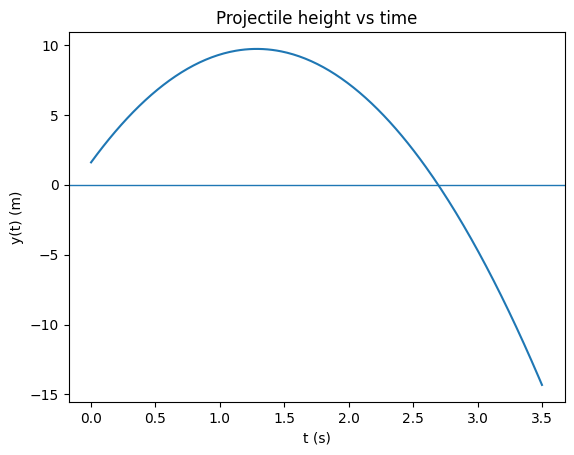

Landing time (bisection): 2.6937120265692105 s  -> y(t) = 1.4139800441625994e-12
Landing time (newton)   : 2.6937120265693126 s  -> y(t) = 0.0
Landing time (secant)   : 2.6937120265693126 s  -> y(t) = 0.0


In [69]:

g = 9.81     # m/s^2
y0 = 1.6     # meters
v0 = 22.0    # m/s
theta = math.radians(35)

def y_of_t(t):
    return y0 + v0*math.sin(theta)*t - 0.5*g*t**2

def dy_dt(t):
    return v0*math.sin(theta) - g*t

# Visualize y(t) to find a bracket for the positive root
ts = np.linspace(0, 3.5, 300)
ys = [y_of_t(t) for t in ts]

plt.figure()
plt.axhline(0, linewidth=1)
plt.plot(ts, ys)
plt.xlabel("t (s)"); plt.ylabel("y(t) (m)")
plt.title("Projectile height vs time")
plt.show()

# Find the positive root
# Rough bracket: t=0 is root too; we want the later one → bracket [0.2, 3.0] for instance
t_bis, _ = bisection(y_of_t, 0.2, 3.0, tol=1e-12)
t_new, _ = newton(y_of_t, dy_dt, x0=2.0, tol=1e-12)
t_sec, _ = secant(y_of_t, 0.2, 3.0, tol=1e-12)

print("Landing time (bisection):", t_bis, "s  -> y(t) =", y_of_t(t_bis))
print("Landing time (newton)   :", t_new,  "s  -> y(t) =", y_of_t(t_new))
print("Landing time (secant)   :", t_sec,  "s  -> y(t) =", y_of_t(t_sec))


## 5. Physical-flavored Example B — Solve $x e^x = 5$


Many physics models lead to transcendental equations. As a tidy example,
solve \(g(x)=x e^x - 5 = 0\). The exact solution is \(x=W(5)\) (Lambert W), but we'll find it numerically.


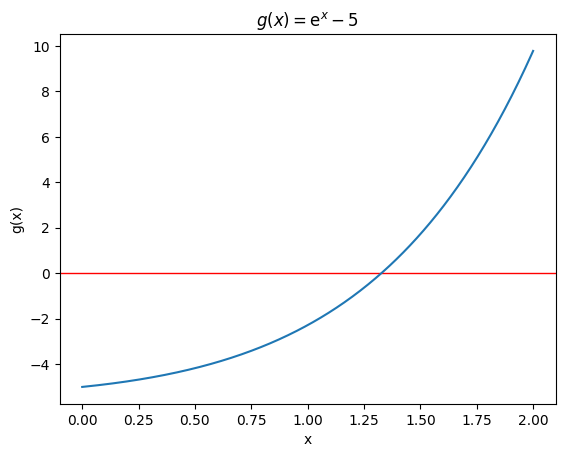

Root (bisection): 1.3267246652419544 g(root) = -2.154720846192504e-12
Root (newton)   : 1.3267246652422002 g(root) = 0.0
Root (secant)   : 1.3267246652422002 g(root) = 0.0


In [11]:

def g(x): 
    return x*np.exp(x) - 5.0

def dg(x): 
    return (x+1.0)*np.exp(x)

xs = np.linspace(0, 2, 400)
plt.figure()
plt.axhline(0, linewidth=1, color = 'red')
plt.plot(xs, g(xs))
# plt.title("g(x) = x exp(x) - 5")
plt.title("$g(x) = \mathrm{e}^x -5 $")
plt.xlabel("x"); plt.ylabel("g(x)")
plt.show()

root_bis2, _ = bisection(g, a=0.5, b=2.0, tol=1e-12)
root_new2, _ = newton(g, dg, x0=1.0, tol=1e-12)
root_sec2, _ = secant(g, 0.5, 2.0, tol=1e-12)

print("Root (bisection):", root_bis2, "g(root) =", g(root_bis2))
print("Root (newton)   :", root_new2, "g(root) =", g(root_new2))
print("Root (secant)   :", root_sec2, "g(root) =", g(root_sec2))


## One stop shopping

In [ ]:
from scipy.optimize import root_scalar

# Our favorite example: f(x) = x^3 - x - 2 (root ~ 1.521...)
f = lambda x: x**3 - x - 2

In [ ]:
# (a) Bracketing method: Brent (needs sign-change bracket)
res_bq = root_scalar(f, bracket=(1.0, 2.0), method="brentq", xtol=1e-12)
print(res_bq.root, res_bq.converged, res_bq.iterations)

In [ ]:
# (b) Newton’s method (needs derivative, no bracket)
df = lambda x: 3*x**2 - 1
res_newton = root_scalar(f, x0=1.5, fprime=df, method="newton", xtol=1e-12)
print(res_newton.root, res_newton.converged)

In [ ]:
# (c) Secant (no derivative; needs two starting guesses)
res_secant = root_scalar(f, x0=1.0, x1=2.0, method="secant", xtol=1e-12)
print(res_secant.root, res_secant.converged)


## 6. Failure modes & practical tips


- **Bisection**: requires f(a)f(b)<0. If not, change the interval or plot first.
- **Newton**: needs a decent initial guess and nonzero derivative; if it diverges or hits a flat slope, try a different guess or switch methods.
- **Secant**: sensitive to starting values; can fail if consecutive f-values are equal or nearly so.
- **Scaling**: Rescale variables so that magnitudes are O(1) if possible.
- **Stopping criteria**: You can stop on small step size |x_{k+1}-x_k|, small residual |f(x_k)|, or max iterations.
---
---

## 7. Exercises


1. **Bracket hunt**: Pick a new nonlinear function, e.g. $f(x)=\cos x - x$.  
   (a) Plot it on $[0, 2]$. (b) Find a bracket with a sign change. (c) Solve with **bisection** to tolerance $10^{-10}$.

2. **Newton pitfalls**: Apply **Newton** to $h(x) = x^{1/3}$ starting at $x_0=0.1$.  
   What happens and why? Modify $h$ or your initial guess to get it to converge to $x=0$.

3. **Secant vs Newton**: For $f(x)=\sin x$ near $x=\pi$, try both methods and compare iteration counts for the same tolerance.

4. **Physics – lens maker’s equation** (thin lens):  
   Given $1/f = (n-1)(1/R_1 - 1/R_2)$ with $f=0.25$ m, $R_1=0.30$ m, $R_2=-0.20$ m, solve for $n$ such that  
   $
   F(n) = \frac{1}{f} - (n-1)\left(\frac{1}{R_1} - \frac{1}{R_2}\right) = 0.
   $
   Use **secant** with two initial guesses.

5. **Convergence plot**: For the test function in $\S$3, record $|f(x_k)|$ for Newton and Secant and make a semilogy plot.  
   Estimate the slope of the line for the last few iterations—does it match expected **quadratic** (Newton) and **superlinear** (~golden ratio for Secant) convergence?


---
## 8. (Optional) Short solution sketches

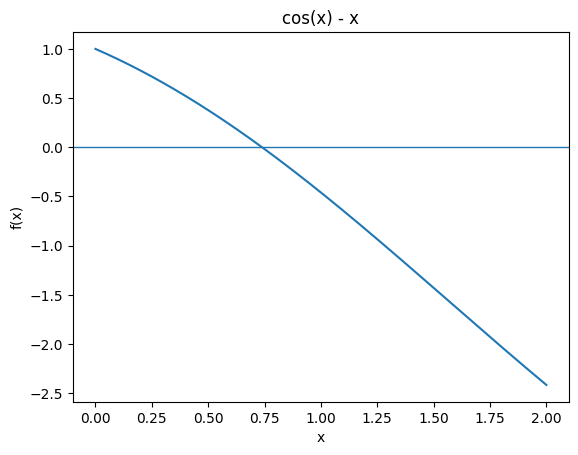

Root ~ 0.7390851332156672 f(root) = -8.47655279301307e-13


In [40]:

# 1. cos x - x on [0, 2]
def f1(x): return np.cos(x) - x
xs = np.linspace(0, 2, 400)
plt.figure()
plt.axhline(0, linewidth=1)
plt.plot(xs, f1(xs))
plt.title("cos(x) - x")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.show()

r1, _ = bisection(f1, 0.0, 1.0, tol=1e-12)  # sign change visible
print("Root ~", r1, "f(root) =", f1(r1))


#### Yikes!! A mishap with newton's method:

In [46]:

# 2. Newton's method on h(x) = x^(1/3)
def h(x): return np.cbrt(x)  # x**(1/3) but safer for negative values of x
def dh(x):
    if x == 0: return np.inf  # derivative singular at 0

    r = np.cbrt(x)
    return (1.0/3.0) / (r*r)   # = (1/3) * x^(-2/3) without fractional power
    
try:
    r2, hist2 = newton(h, dh, x0=0.1, tol=1e-12, max_iter=50)
    print("Newton result:", r2, "h(r2)=", h(r2))
except Exception as e:
    print("Newton failed:", type(e).__name__, e)


Newton result: 112589990684262.47 h(r2)= 48287.33765897929


In [42]:

# 3. sin near pi
def f3(x): return np.sin(x)
def df3(x): return np.cos(x)
r3n, hist3n = newton(f3, df3, x0=3.0, tol=1e-12)
r3s, hist3s = secant(f3, 2.5, 3.5, tol=1e-12)
print("Newton ~", r3n, "|f|:", f3(r3n), "iters:", len(hist3n))
print("Secant ~", r3s, "|f|:", f3(r3s), "iters:", len(hist3s))


Newton ~ 3.141592653589793 |f|: 1.2246467991473532e-16 iters: 4
Secant ~ 3.141592653589793 |f|: 1.2246467991473532e-16 iters: 6


In [43]:

# 4. Lens maker's equation solve for n
f = 0.25
R1, R2 = 0.30, -0.20
def F(n): return 1.0/f - (n-1.0)*(1.0/R1 - 1.0/R2)
n_root, _ = secant(F, 1.2, 1.7, tol=1e-12)
print("n ~", n_root, "F(n)=", F(n_root))


n ~ 1.48 F(n)= 0.0


### Estimate convergence rate (optional).

In [45]:
def slope_last_polyfit(hist, k=5):
    hist = np.asarray(hist, float)
    mask = np.isfinite(hist) & (hist > 0)
    hist = hist[mask]
    n = hist.size
    if n < 2:
        raise ValueError("Need at least 2 positive, finite points to fit a slope.")
    m = min(k, n)
    y = np.log(hist[-m:])
    x = np.arange(n - m, n, dtype=float)
    slope, intercept = np.polyfit(x, y, deg=1)
    return slope

_, hN = newton(lambda x: x**3 - x - 2, lambda x: 3*x**2 - 1, x0=1.5)
_, hS = secant(lambda x: x**3 - x - 2, 1.0, 2.0)

print("Approx slope (Newton):", slope_last_polyfit(hN))
print("Approx slope (Secant):", slope_last_polyfit(hS))
print("(Interpret slopes in log(|f|) vs iter; expect faster drop for Newton.)")


Approx slope (Newton): -9.41340715514852
Approx slope (Secant): -7.04346448159351
(Interpret slopes in log(|f|) vs iter; expect faster drop for Newton.)
